# Task 5 - Level 1: Regression Assignment (California Housing)

**Name:** Abdlrhman Hisham Ismail  
**ID:** AI2617

This notebook builds and evaluates linear regression models for predicting **median house value** using:
1. **Linear Regression from scratch** (Normal Equation)
2. **Linear Regression from scratch** (Gradient Descent)
3. **Scikit-learn Linear Regression**

The data is split into **70% train / 15% validation / 15% test**. The test set is used only for final evaluation.


## 1) Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

np.random.seed(42)
pd.set_option('display.max_columns', None)


## 2) Load Dataset and Quick Inspection

In [2]:
df = pd.read_csv('housing.csv')
print('Shape:', df.shape)
df.head()

Shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


In [5]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

## 3) Preprocessing

- Fill missing numeric values (if any) using **median of training distribution approach** (here done before split only for simplicity in this assignment context).
- One-hot encode `ocean_proximity`.
- Separate features/target.


In [6]:
# Handle missing values
if 'total_bedrooms' in df.columns:
    df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

# One-hot encode categorical column
df_encoded = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

# Features and target
y = df_encoded['median_house_value'].values.reshape(-1, 1)
X = df_encoded.drop(columns=['median_house_value']).astype(float).values

print('Encoded feature matrix shape:', X.shape)
print('Target shape:', y.shape)

Encoded feature matrix shape: (20640, 12)
Target shape: (20640, 1)


## 4) Random Train / Validation / Test Split (70 / 15 / 15)

Split is performed by random permutation of row indices.


In [7]:
n = X.shape[0]
indices = np.random.permutation(n)

train_end = int(0.70 * n)
val_end = int(0.85 * n)

train_idx = indices[:train_end]
val_idx = indices[train_end:val_end]
test_idx = indices[val_end:]

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

print('Train:', X_train.shape, y_train.shape)
print('Val  :', X_val.shape, y_val.shape)
print('Test :', X_test.shape, y_test.shape)

Train: (14447, 12) (14447, 1)
Val  : (3097, 12) (3097, 1)
Test : (3096, 12) (3096, 1)


## 5) Feature Scaling (for Gradient Descent stability)

Scaling parameters are computed from **training set only** and applied to validation/test.


In [8]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
std[std == 0] = 1.0

X_train_scaled = (X_train - mean) / std
X_val_scaled = (X_val - mean) / std
X_test_scaled = (X_test - mean) / std


def add_bias(X_mat):
    return np.c_[np.ones((X_mat.shape[0], 1)), X_mat]

X_train_b = add_bias(X_train_scaled)
X_val_b = add_bias(X_val_scaled)
X_test_b = add_bias(X_test_scaled)

## 6) Metrics from Scratch (MSE, MAE)

As required, both metrics are implemented manually using NumPy operations.


In [9]:
def mse(y_true, y_pred):
    err = y_true - y_pred
    return np.mean(err ** 2)


def mae(y_true, y_pred):
    err = y_true - y_pred
    return np.mean(np.abs(err))

## 7) Linear Regression from Scratch — Normal Equation

Closed-form solution:  
\( w = (X^T X)^{-1} X^T y \)

We use `np.linalg.pinv` for numerical stability.


In [10]:
w_ne = np.linalg.pinv(X_train_b.T @ X_train_b) @ X_train_b.T @ y_train

y_train_pred_ne = X_train_b @ w_ne
y_val_pred_ne = X_val_b @ w_ne
y_test_pred_ne = X_test_b @ w_ne

print('Normal Equation weights shape:', w_ne.shape)
print('Val MSE:', round(mse(y_val, y_val_pred_ne), 2))
print('Val MAE:', round(mae(y_val, y_val_pred_ne), 2))

Normal Equation weights shape: (13, 1)
Val MSE: 4577524307.67
Val MAE: 49468.86


## 8) Linear Regression from Scratch — Gradient Descent

Update rule:  
\( w := w - lpha 
abla J(w) \)

Where for MSE cost:
\( 
abla J(w) = rac{2}{m} X^T(Xw - y) \)


In [11]:
def gradient_descent(X, y, lr=0.01, n_iters=3000):
    m, n_features = X.shape
    w = np.zeros((n_features, 1))
    history = []

    for _ in range(n_iters):
        preds = X @ w
        grad = (2 / m) * (X.T @ (preds - y))
        w -= lr * grad
        history.append(mse(y, X @ w))

    return w, history


learning_rates = [0.001, 0.003, 0.01, 0.03, 0.1]
results_gd = []

for lr in learning_rates:
    w_tmp, hist_tmp = gradient_descent(X_train_b, y_train, lr=lr, n_iters=4000)
    val_pred_tmp = X_val_b @ w_tmp
    results_gd.append((lr, w_tmp, hist_tmp, mse(y_val, val_pred_tmp), mae(y_val, val_pred_tmp)))

best_lr, w_gd, gd_history, best_val_mse, best_val_mae = min(results_gd, key=lambda x: x[3])

print('Best learning rate:', best_lr)
print('Best GD Validation MSE:', round(best_val_mse, 2))
print('Best GD Validation MAE:', round(best_val_mae, 2))

Best learning rate: 0.01
Best GD Validation MSE: 4573166412.34
Best GD Validation MAE: 49348.95


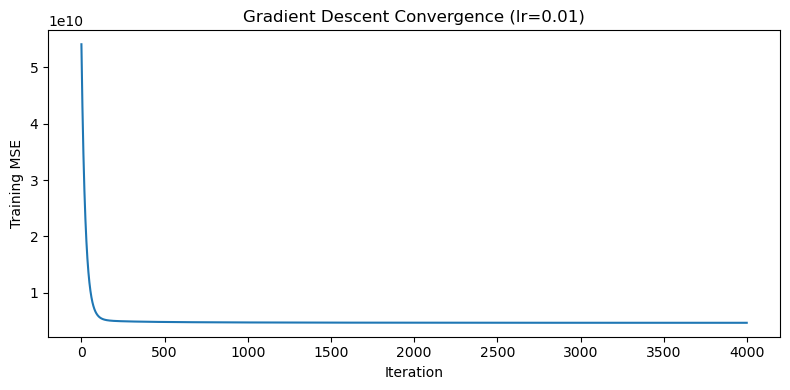

In [12]:
y_train_pred_gd = X_train_b @ w_gd
y_val_pred_gd = X_val_b @ w_gd
y_test_pred_gd = X_test_b @ w_gd

plt.figure(figsize=(8, 4))
plt.plot(gd_history)
plt.title(f'Gradient Descent Convergence (lr={best_lr})')
plt.xlabel('Iteration')
plt.ylabel('Training MSE')
plt.tight_layout()
plt.show()

## 9) Scikit-learn Linear Regression

For fair comparison, sklearn is trained on the same scaled features.


In [13]:
sk_model = LinearRegression()
sk_model.fit(X_train_scaled, y_train)

y_train_pred_sk = sk_model.predict(X_train_scaled)
y_val_pred_sk = sk_model.predict(X_val_scaled)
y_test_pred_sk = sk_model.predict(X_test_scaled)

print('Sklearn model fitted.')

Sklearn model fitted.


## 10) Compare All Models (Train / Validation / Test)

Metrics are computed with the custom `mse` and `mae` functions.


In [14]:
rows = []

def add_result(model_name, y_tr, y_tr_pred, y_v, y_v_pred, y_te, y_te_pred):
    rows.append({
        'Model': model_name,
        'Train MSE': mse(y_tr, y_tr_pred),
        'Train MAE': mae(y_tr, y_tr_pred),
        'Val MSE': mse(y_v, y_v_pred),
        'Val MAE': mae(y_v, y_v_pred),
        'Test MSE': mse(y_te, y_te_pred),
        'Test MAE': mae(y_te, y_te_pred),
    })

add_result('From Scratch - Normal Equation', y_train, y_train_pred_ne, y_val, y_val_pred_ne, y_test, y_test_pred_ne)
add_result('From Scratch - Gradient Descent', y_train, y_train_pred_gd, y_val, y_val_pred_gd, y_test, y_test_pred_gd)
add_result('Scikit-learn - LinearRegression', y_train, y_train_pred_sk, y_val, y_val_pred_sk, y_test, y_test_pred_sk)

results_df = pd.DataFrame(rows)
for col in results_df.columns[1:]:
    results_df[col] = results_df[col].round(2)

results_df

,Model,Train MSE,Train MAE,Val MSE,Val MAE,Test MSE,Test MAE
0,From Scratch - Normal Equation,4.677652e+09,49778.90,4.577524e+09,49468.86,5.111575e+09,50857.33
1,From Scratch - Gradient Descent,4.679862e+09,49717.87,4.573166e+09,49348.95,5.100284e+09,50763.47
2,Scikit-learn - LinearRegression,4.677652e+09,49778.90,4.577524e+09,49468.86,5.111575e+09,50857.33


## 11) Discussion: Closed-form vs Gradient Descent vs Scikit-learn

### Closed-form (Normal Equation)
- Provides a direct analytical solution without iterative updates.
- Fast and exact for moderate feature sizes.
- May be less practical for very large feature spaces due to matrix operations.

### Gradient Descent
- Iterative optimization approach.
- Requires careful choice of learning rate and enough iterations.
- Feature scaling significantly improves convergence speed and stability.

### Scikit-learn Linear Regression
- Efficient and production-ready implementation.
- Usually matches from-scratch closed-form performance (up to numerical tolerance).
- Best choice for practical workflows unless educational implementation is required.

In this assignment, results should be close across the three methods, with differences mainly from optimization settings and numerical precision.


## 12) Final Conclusion

- The California Housing regression task was completed with the required **70/15/15** split.
- **MSE** and **MAE** were implemented from scratch and used for all evaluations.
- Linear regression was implemented from scratch using both **Normal Equation** and **Gradient Descent**, then compared against **Scikit-learn**.
- The validation set was used for tuning Gradient Descent learning rate; the test set was used only for final model comparison.
